In [65]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import re
from rapidfuzz import fuzz

In [66]:
def normalize_text(s):
    """Basic text normalization: strip, lowercase, remove articles, collapse whitespace, strip trailing punctuation."""
    if pd.isna(s):
        return s
    s = str(s).strip().lower()
    # remove leading articles
    s = re.sub(r'^(a|an|the)\s+', '', s)
    # collapse multiple spaces
    s = re.sub(r'\s+', ' ', s)
    # strip trailing punctuation
    s = re.sub(r'[.,;:!?]+$', '', s)
    return s.strip()


def normalize_and_dedup(series, fuzzy_threshold=85, max_unique_for_fuzzy=500):
    """Normalize a pandas Series and fuzzy-dedup near-duplicate values.
    
    1. Apply basic text normalization (lowercase, strip articles, etc.)
    2. If unique count <= max_unique_for_fuzzy, run fuzzy dedup using rapidfuzz:
       - Sort unique values by frequency (most common first)
       - Greedily merge less-common values into the most-common similar canonical form
    """
    # step 1: basic normalization
    normed = series.map(normalize_text)
    
    # step 2: fuzzy dedup (skip for high-cardinality columns)
    unique_vals = normed.dropna().unique()
    if len(unique_vals) > max_unique_for_fuzzy:
        print(f'  Skipping fuzzy dedup ({len(unique_vals)} unique > {max_unique_for_fuzzy})')
        return normed
    
    # sort by frequency descending so the most common form becomes canonical
    freq = normed.value_counts()
    sorted_vals = freq.index.tolist()
    
    canonical_map = {}  # normalized value -> canonical form
    canonicals = []     # list of canonical forms (in order of frequency)
    
    for val in sorted_vals:
        if pd.isna(val):
            continue
        matched = False
        for canon in canonicals:
            if fuzz.ratio(val, canon) >= fuzzy_threshold:
                canonical_map[val] = canon
                matched = True
                break
        if not matched:
            canonicals.append(val)
            canonical_map[val] = val
    
    merged_count = sum(1 for k, v in canonical_map.items() if k != v)
    if merged_count > 0:
        print(f'  Fuzzy dedup merged {merged_count} values into existing canonical forms')
    
    return normed.map(lambda x: canonical_map.get(x, x))

In [67]:
ci_flows_1984 = pd.read_parquet('/share/pierson/matt/UAIR/outputs/2026-02-10/08-02-59/ci_extraction_1984/outputs/ci_extraction/ci_flows.parquet')
ci_flows_pandp = pd.read_parquet('/share/pierson/matt/UAIR/outputs/2026-02-09/10-03-34/ci_extraction/outputs/ci_extraction/ci_flows.parquet')

In [68]:
cols_to_normalize = [
    'ci_context', 'ci_flow_context', 'ci_subject', 'ci_sender',
    'ci_recipient', 'ci_information_type', 'ci_transmission_principle',
    'ci_norms_invoked', 'ci_norm_source',
]

for col in cols_to_normalize:
    print(f'Normalizing {col} ...')
    ci_flows_1984[col] = normalize_and_dedup(ci_flows_1984[col])
    ci_flows_pandp[col] = normalize_and_dedup(ci_flows_pandp[col])
    print()

Normalizing ci_context ...
  Fuzzy dedup merged 4 values into existing canonical forms
  Fuzzy dedup merged 2 values into existing canonical forms

Normalizing ci_flow_context ...
  Fuzzy dedup merged 2 values into existing canonical forms

Normalizing ci_subject ...
  Fuzzy dedup merged 5 values into existing canonical forms
  Fuzzy dedup merged 31 values into existing canonical forms

Normalizing ci_sender ...
  Fuzzy dedup merged 10 values into existing canonical forms
  Fuzzy dedup merged 13 values into existing canonical forms

Normalizing ci_recipient ...
  Fuzzy dedup merged 10 values into existing canonical forms
  Fuzzy dedup merged 36 values into existing canonical forms

Normalizing ci_information_type ...
  Fuzzy dedup merged 14 values into existing canonical forms
  Fuzzy dedup merged 7 values into existing canonical forms

Normalizing ci_transmission_principle ...

Normalizing ci_norms_invoked ...
  Skipping fuzzy dedup (1206 unique > 500)
  Skipping fuzzy dedup (1686 uni

In [69]:
ci_flows_1984.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1234 entries, 0 to 1233
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   gutenberg_id               1234 non-null   object 
 1   chunk_id                   1234 non-null   int64  
 2   article_text               1234 non-null   object 
 3   chunk_size                 1234 non-null   int64  
 4   article_path               1234 non-null   object 
 5   country                    1234 non-null   object 
 6   year                       1234 non-null   object 
 7   article_id                 1234 non-null   object 
 8   ci_reasoning_json          1234 non-null   object 
 9   ci_reasoning_parse_error   0 non-null      object 
 10  generated_text             1234 non-null   object 
 11  has_information_exchange   1234 non-null   bool   
 12  ci_flow_count              1234 non-null   int64  
 13  ci_flow_index              1234 non-null   int64

In [70]:
# compare the distribution of ci_context between the two dataframes 
# union all possible ci_contexts in the two dataframes 
ci_contexts_union = np.union1d(
    ci_flows_1984['ci_context'].unique(),
    ci_flows_pandp['ci_context'].unique(),
)

# get the counts of each ci_context, reindexed to the full union
ci_context_counts_1984 = ci_flows_1984['ci_context'].value_counts().reindex(ci_contexts_union, fill_value=0)
ci_context_counts_pandp = ci_flows_pandp['ci_context'].value_counts().reindex(ci_contexts_union, fill_value=0)

# create a new dataframe with the union of ci_contexts and the counts 
ci_context_counts = pd.DataFrame({
    'ci_context': ci_contexts_union,
    'count_1984': ci_context_counts_1984.values,
    'count_pandp': ci_context_counts_pandp.values,
})
ci_context_counts['sum_counts'] = ci_context_counts['count_1984'] + ci_context_counts['count_pandp']
# sort descending by sum of counts 
ci_context_counts = ci_context_counts.sort_values(by='sum_counts', ascending=False)


In [71]:
ci_context_counts 

,ci_context,count_1984,count_pandp,sum_counts
11,courtship,102,919,1021
144,state/political,535,0,535
125,social etiquette,58,390,448
24,family,26,356,382
145,surveillance,125,0,125
...,...,...,...,...
148,torture,1,0,1
150,travel and social interaction,0,1,1
149,tour of the house,0,1,1
152,war and society,1,0,1


/tmp/ipykernel_3932850/1407842423.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{abs(t):.0f}%' for t in ticks])


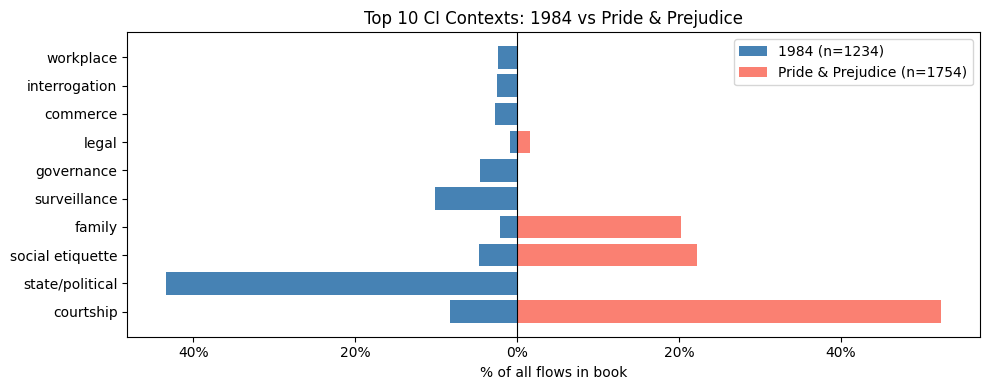

In [72]:
# plot the top 10 ci_contexts with two-sided symmetric bar plot (normalized to % of all flows)
ci_context_counts_top10 = ci_context_counts.head(10).copy()

total_1984 = ci_flows_1984.shape[0]
total_pandp = ci_flows_pandp.shape[0]
ci_context_counts_top10['pct_1984'] = ci_context_counts_top10['count_1984'].fillna(0) / total_1984 * 100
ci_context_counts_top10['pct_pandp'] = ci_context_counts_top10['count_pandp'].fillna(0) / total_pandp * 100

fig, ax = plt.subplots(figsize=(10, 4))
y_pos = range(len(ci_context_counts_top10))
labels = ci_context_counts_top10['ci_context']

ax.barh(y_pos, -ci_context_counts_top10['pct_1984'], color='steelblue', label=f'1984 (n={total_1984})')
ax.barh(y_pos, ci_context_counts_top10['pct_pandp'], color='salmon', label=f'Pride & Prejudice (n={total_pandp})')

ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.set_xlabel('% of all flows in book')
ax.set_title('Top 10 CI Contexts: 1984 vs Pride & Prejudice')
ax.legend()
ax.axvline(0, color='black', linewidth=0.8)
# label x-axis with absolute values
ticks = ax.get_xticks()
ax.set_xticklabels([f'{abs(t):.0f}%' for t in ticks])

plt.tight_layout()
plt.show()






In [73]:
ci_flows_1984['ci_context'].value_counts()

ci_context
state/political                        535
surveillance                           125
courtship                              102
social etiquette                        58
governance                              57
                                      ... 
narrative                                1
education, political                     1
language and ideology                    1
historical and political commentary      1
cultural heritage                        1
Name: count, Length: 134, dtype: int64

/tmp/ipykernel_3932850/4147788992.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{abs(t):.0f}%' for t in ticks])


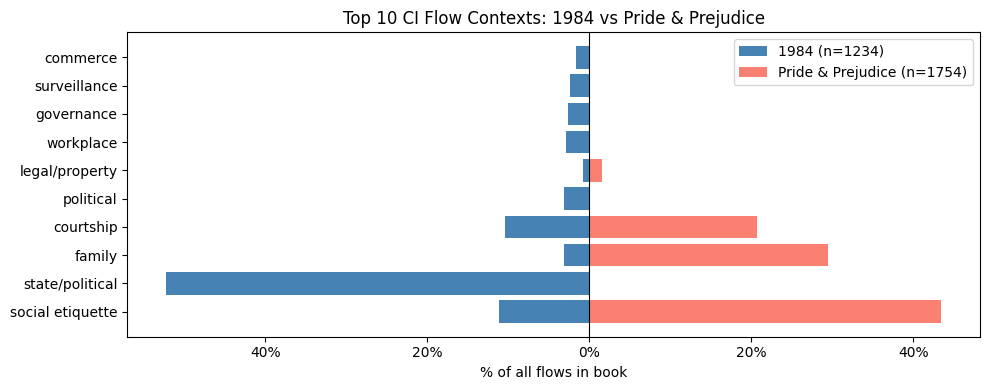

In [74]:
# repeat above plot for ci_flow_context 
ci_flow_contexts_union = np.union1d(
    ci_flows_1984['ci_flow_context'].unique(),
    ci_flows_pandp['ci_flow_context'].unique(),
)

# get the counts of each ci_flow_context, reindexed to the full union
ci_flow_context_counts_1984 = ci_flows_1984['ci_flow_context'].value_counts().reindex(ci_flow_contexts_union, fill_value=0)
ci_flow_context_counts_pandp = ci_flows_pandp['ci_flow_context'].value_counts().reindex(ci_flow_contexts_union, fill_value=0)

ci_flow_context_counts = pd.DataFrame({
    'ci_flow_context': ci_flow_contexts_union,
    'count_1984': ci_flow_context_counts_1984.values,
    'count_pandp': ci_flow_context_counts_pandp.values,
})
ci_flow_context_counts['sum_counts'] = ci_flow_context_counts['count_1984'] + ci_flow_context_counts['count_pandp']
ci_flow_context_counts = ci_flow_context_counts.sort_values(by='sum_counts', ascending=False)

ci_flow_context_counts_top10 = ci_flow_context_counts.head(10).copy()

total_1984 = ci_flows_1984.shape[0]
total_pandp = ci_flows_pandp.shape[0]
ci_flow_context_counts_top10['pct_1984'] = ci_flow_context_counts_top10['count_1984'].fillna(0) / total_1984 * 100
ci_flow_context_counts_top10['pct_pandp'] = ci_flow_context_counts_top10['count_pandp'].fillna(0) / total_pandp * 100

fig, ax = plt.subplots(figsize=(10, 4))
y_pos = range(len(ci_flow_context_counts_top10))
labels = ci_flow_context_counts_top10['ci_flow_context']

ax.barh(y_pos, -ci_flow_context_counts_top10['pct_1984'], color='steelblue', label=f'1984 (n={total_1984})')
ax.barh(y_pos, ci_flow_context_counts_top10['pct_pandp'], color='salmon', label=f'Pride & Prejudice (n={total_pandp})')

ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.set_xlabel('% of all flows in book')
ax.set_title('Top 10 CI Flow Contexts: 1984 vs Pride & Prejudice')
ax.legend()
ax.axvline(0, color='black', linewidth=0.8)
# label x-axis with absolute values
ticks = ax.get_xticks()
ax.set_xticklabels([f'{abs(t):.0f}%' for t in ticks])

plt.tight_layout()
plt.show()





/tmp/ipykernel_3932850/4160774872.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{abs(t):.0f}%' for t in ticks])


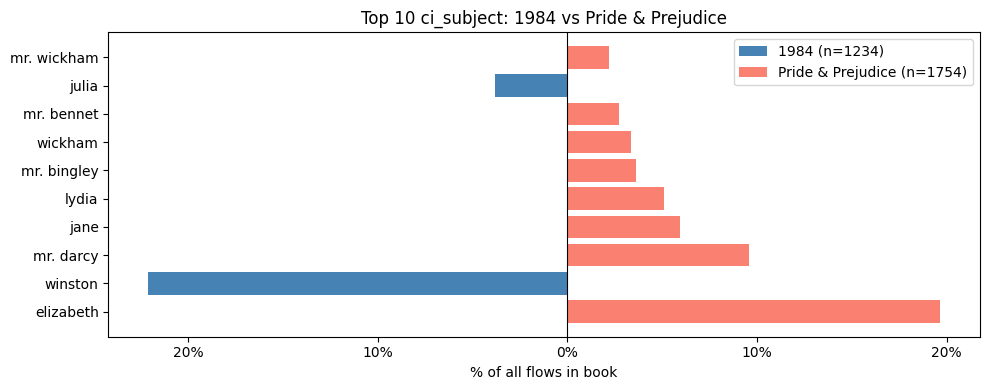

/tmp/ipykernel_3932850/4160774872.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{abs(t):.0f}%' for t in ticks])


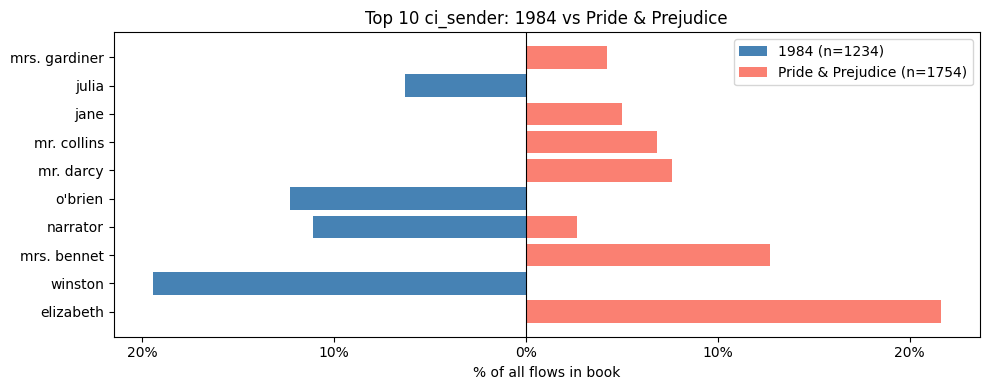

/tmp/ipykernel_3932850/4160774872.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{abs(t):.0f}%' for t in ticks])


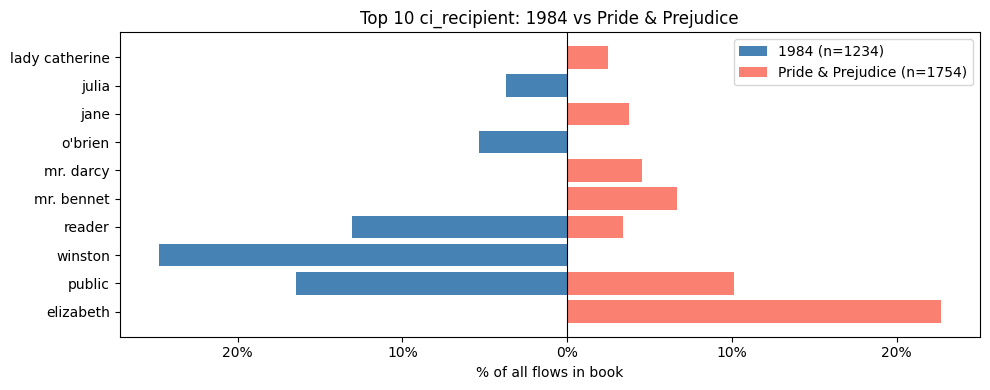

/tmp/ipykernel_3932850/4160774872.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{abs(t):.0f}%' for t in ticks])


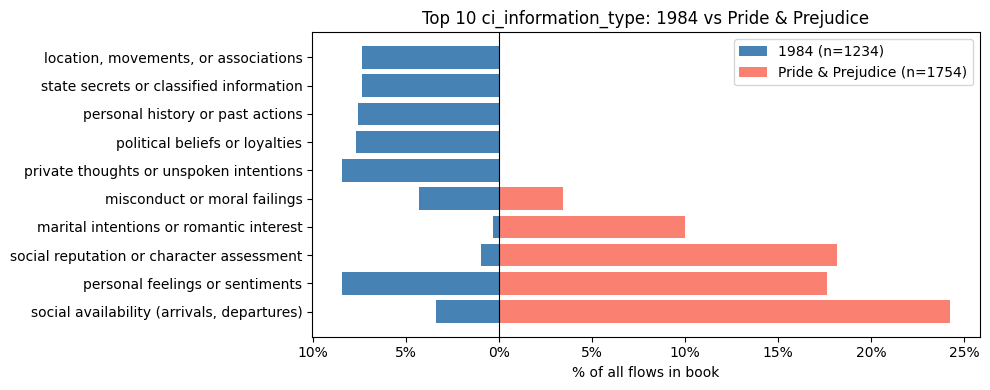

/tmp/ipykernel_3932850/4160774872.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{abs(t):.0f}%' for t in ticks])


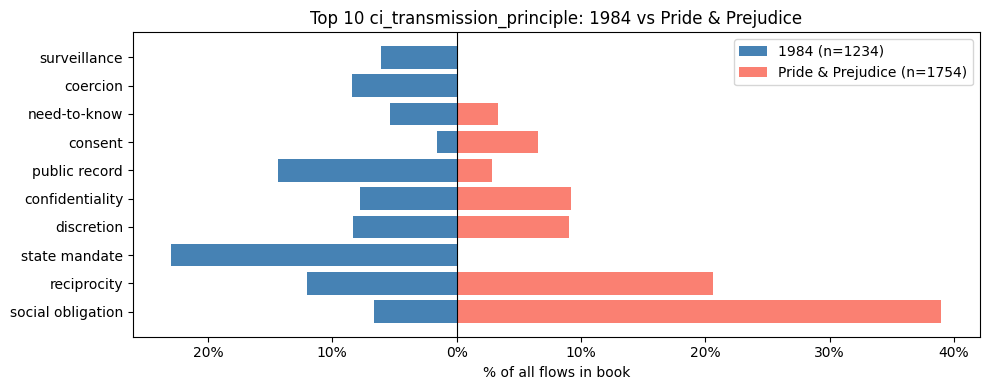

/tmp/ipykernel_3932850/4160774872.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{abs(t):.0f}%' for t in ticks])
/tmp/ipykernel_3932850/4160774872.py:48: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


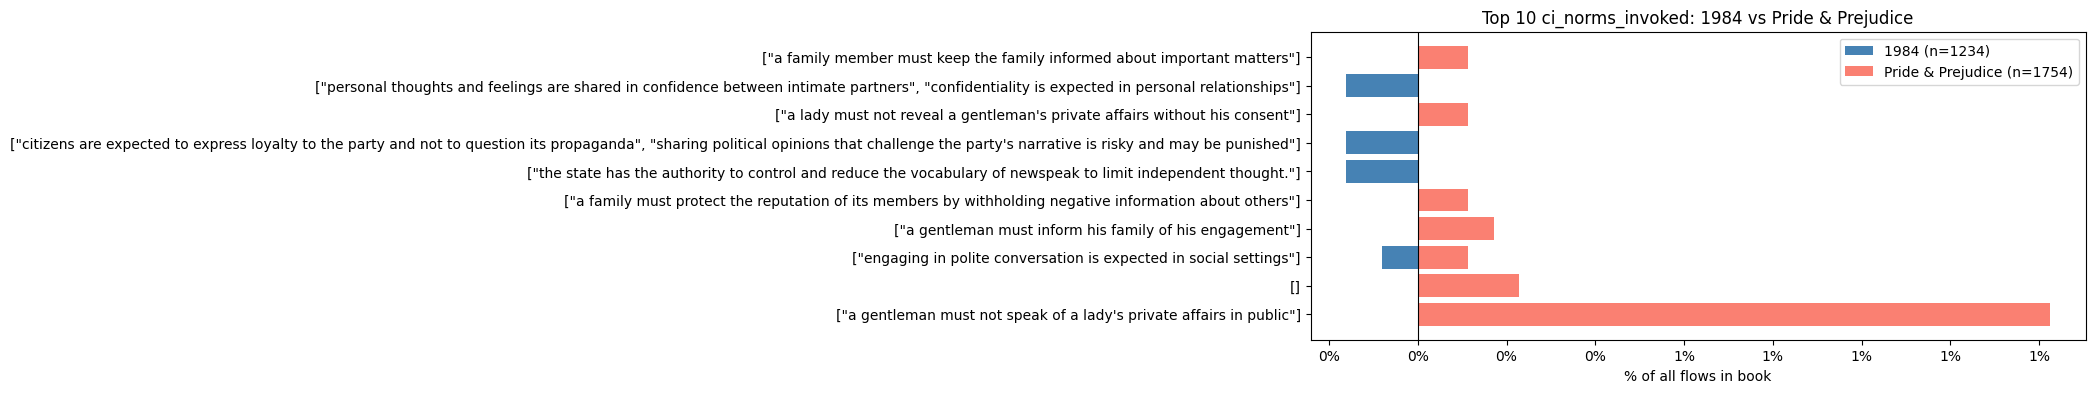

/tmp/ipykernel_3932850/4160774872.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{abs(t):.0f}%' for t in ticks])


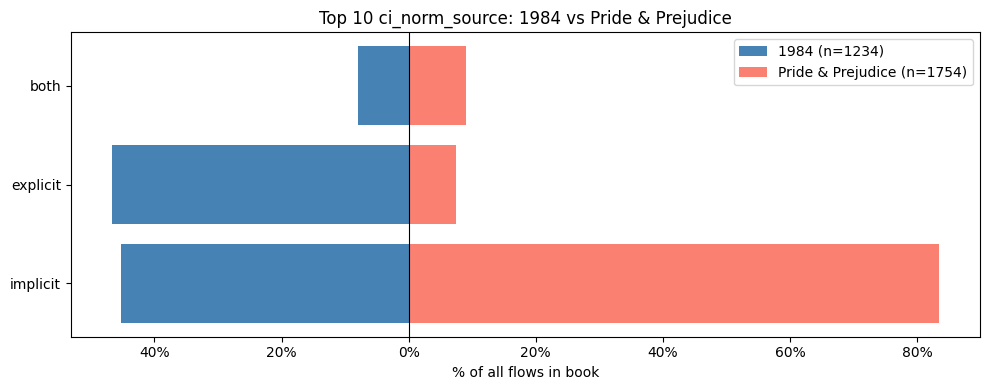

In [75]:
columns_to_plot = [
    'ci_subject', 'ci_sender', 'ci_recipient',
    'ci_information_type', 'ci_transmission_principle',
    'ci_norms_invoked', 'ci_norm_source',
]

total_1984 = ci_flows_1984.shape[0]
total_pandp = ci_flows_pandp.shape[0]

for col in columns_to_plot:
    # build union of all unique values
    union_vals = np.union1d(
        ci_flows_1984[col].dropna().unique(),
        ci_flows_pandp[col].dropna().unique(),
    )

    # reindex counts to the union so alignment is correct
    counts_1984 = ci_flows_1984[col].value_counts().reindex(union_vals, fill_value=0)
    counts_pandp = ci_flows_pandp[col].value_counts().reindex(union_vals, fill_value=0)

    df = pd.DataFrame({
        col: union_vals,
        'count_1984': counts_1984.values,
        'count_pandp': counts_pandp.values,
    })
    df['sum_counts'] = df['count_1984'] + df['count_pandp']
    df = df.sort_values(by='sum_counts', ascending=False).head(10).copy()

    df['pct_1984'] = df['count_1984'] / total_1984 * 100
    df['pct_pandp'] = df['count_pandp'] / total_pandp * 100

    fig, ax = plt.subplots(figsize=(10, 4))
    y_pos = range(len(df))
    labels = df[col]

    ax.barh(y_pos, -df['pct_1984'], color='steelblue', label=f'1984 (n={total_1984})')
    ax.barh(y_pos, df['pct_pandp'], color='salmon', label=f'Pride & Prejudice (n={total_pandp})')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels)
    ax.set_xlabel('% of all flows in book')
    ax.set_title(f'Top 10 {col}: 1984 vs Pride & Prejudice')
    ax.legend()
    ax.axvline(0, color='black', linewidth=0.8)
    ticks = ax.get_xticks()
    ax.set_xticklabels([f'{abs(t):.0f}%' for t in ticks])

    plt.tight_layout()
    plt.show()